In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv('earthquake_1995-2023.csv')

print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (1000, 19)


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [4]:
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [5]:
full_dupes = df.duplicated()
print(f"Fully identical duplicate rows: {full_dupes.sum()}")
key_dupes = df.duplicated(subset=['title', 'date_time'])
print(f"Duplicate earthquakes (title + date_time): {key_dupes.sum()}")
df[df.duplicated(subset=['title', 'date_time'], keep=False)].sort_values(['title', 'date_time'])


Fully identical duplicate rows: 0
Duplicate earthquakes (title + date_time): 2


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
67,"M 6.5 - 71 km SE of Nikolski, Alaska",6.5,11/01/2022 12:39,0,3,NaN,1,650,at,97,1.616070,108.0,Mi,37.0,52.502,-168.080,"Nikolski, Alaska",NaN,NaN
68,"M 6.5 - 71 km SE of Nikolski, Alaska",6.5,11/01/2022 12:39,0,3,NaN,1,650,pt,23,0.000000,208.8,Mi,37.0,52.502,-168.080,"Nikolski, Alaska",NaN,NaN
70,"M 6.7 - 91 km SE of Nikolski, Alaska",6.7,11/01/2022 11:35,0,4,NaN,1,691,at,50,0.936943,126.0,Mi,33.0,52.480,-167.736,"Nikolski, Alaska",NaN,NaN
71,"M 6.7 - 91 km SE of Nikolski, Alaska",6.7,11/01/2022 11:35,0,4,NaN,1,691,pt,20,0.000000,205.2,Mi,33.0,52.480,-167.736,"Nikolski, Alaska",NaN,NaN


In [6]:
print(f"Row count BEFORE removing duplicates: {df.shape[0]}")

df = df.drop_duplicates(subset=['title', 'date_time']).reset_index(drop=True)

print(f"Row count AFTER removing duplicates:  {df.shape[0]}")


Row count BEFORE removing duplicates: 1000
Row count AFTER removing duplicates:  998


In [7]:
missing_report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_report


,missing_count,missing_pct
continent,714,71.54
alert,549,55.01
country,347,34.77
location,6,0.60


In [8]:
candidate_cols = ['cdi', 'gap', 'nst', 'dmin']

for col in candidate_cols:
    n_zero = (df[col] == 0).sum()
    print(f"{col:>6}: {n_zero} zero values ({n_zero/len(df)*100:.1f}% of rows)")


   cdi: 395 zero values (39.6% of rows)
   gap: 252 zero values (25.3% of rows)
   nst: 519 zero values (52.0% of rows)
  dmin: 586 zero values (58.7% of rows)


In [9]:
for col in candidate_cols:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after unmasking disguised zeros:")
df[candidate_cols].isnull().sum()


Missing values after unmasking disguised zeros:


,0
cdi,395
gap,252
nst,519
dmin,586


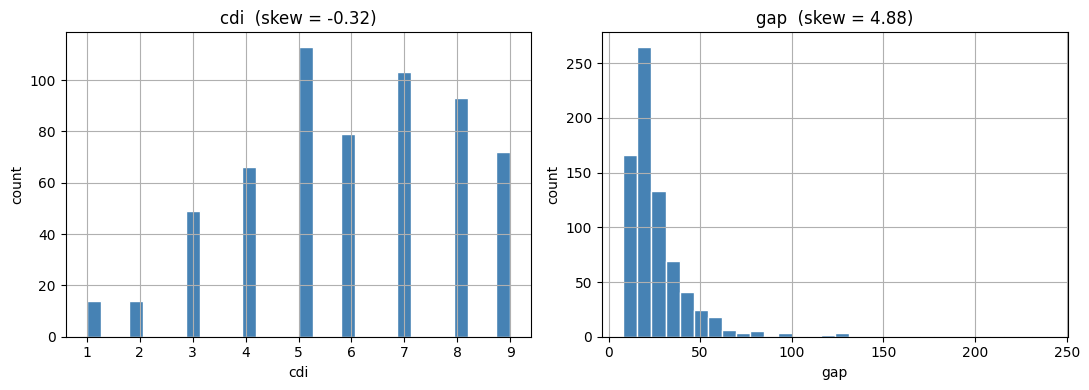

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ['cdi', 'gap']):
    df[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"{col}  (skew = {skew(df[col].dropna()):.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

In [11]:
df['cdi'] = df['cdi'].fillna(df['cdi'].mean())
df['gap'] = df['gap'].fillna(df['gap'].median())


df['nst'] = df['nst'].fillna(df['nst'].mean())
df['dmin'] = df['dmin'].fillna(df['dmin'].median())

print("Remaining missing values in numeric columns:")
df[candidate_cols].isnull().sum()

Remaining missing values in numeric columns:


,0
cdi,0
gap,0
nst,0
dmin,0


In [12]:
alert_mode = df['alert'].mode()[0]
print("Mode of 'alert':", alert_mode)
df['alert'] = df['alert'].fillna(alert_mode)

for col in ['location', 'continent', 'country']:
    df[col] = df[col].fillna('Unknown')

df[['alert', 'location', 'continent', 'country']].isnull().sum()

Mode of 'alert': green


,0
alert,0
location,0
continent,0
country,0


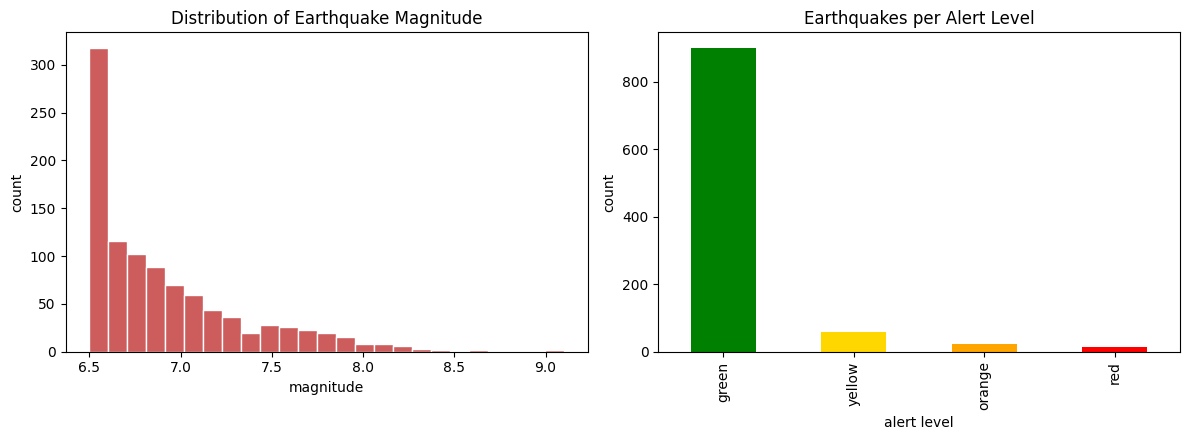

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))


axes[0].hist(df['magnitude'], bins=25, color='indianred', edgecolor='white')
axes[0].set_title('Distribution of Earthquake Magnitude')
axes[0].set_xlabel('magnitude')
axes[0].set_ylabel('count')

order = ['green', 'yellow', 'orange', 'red']
df['alert'].value_counts().reindex(order).plot(kind='bar', ax=axes[1],
                                                 color=['green', 'gold', 'orange', 'red'])
axes[1].set_title('Earthquakes per Alert Level')
axes[1].set_xlabel('alert level')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


In [14]:
remaining = df.isnull().sum().sum()
print(f"Total remaining missing values in the cleaned dataset: {remaining}")
assert remaining == 0, "There are still missing values left to handle!"
print("Dataset is clean and analysis-ready.")
df.head()

Total remaining missing values in the cleaned dataset: 0
Dataset is clean and analysis-ready.


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16/08/2023 12:47,7.000000,4,green,0,657,us,114.0,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",Unknown,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19/07/2023 00:22,8.000000,6,yellow,0,775,us,92.0,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",Unknown,Unknown
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17/07/2023 03:05,7.000000,5,green,0,899,us,70.0,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16/07/2023 06:48,6.000000,6,green,1,860,us,173.0,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",Unknown,Unknown
4,M 7.3 - Alaska Peninsula,7.3,16/07/2023 06:48,5.978441,5,green,1,820,at,79.0,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,Unknown,Unknown
